<a href="https://colab.research.google.com/github/lalitha-sahitya/Handwritten-digit-recognition/blob/main/ieee_digit_competition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt

In [69]:
!pip install opendatasets

In [70]:
import opendatasets as od
od.download('https://www.kaggle.com/competitions/ieee-digit-competition-2')

Skipping, found downloaded files in "./ieee-digit-competition-2" (use force=True to force download)


In [71]:
os.listdir('ieee-digit-competition-2/')

['test.csv', 'train.csv', 'sample_submission.csv']

In [72]:
data=pd.read_csv('/content/ieee-digit-competition-2/train.csv')
test_data=pd.read_csv('/content/ieee-digit-competition-2/test.csv')

In [73]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [74]:
test_data.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [75]:
labels=data['label']

In [76]:
labels=np.array(labels)

In [77]:
labels

array([1, 0, 1, ..., 7, 6, 9])

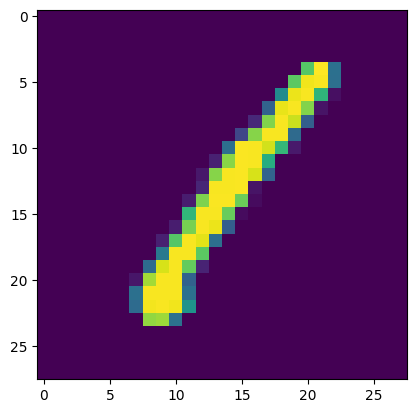

In [78]:
plt.imshow(data.iloc[0,1:].values.reshape(28,28))

In [79]:
data=data.drop('label',axis=1)

In [80]:
train=[]
for i in range(len(data)):
  train.append(data.iloc[i,].values.reshape(28,28))

In [81]:
train[0].shape

(28, 28)

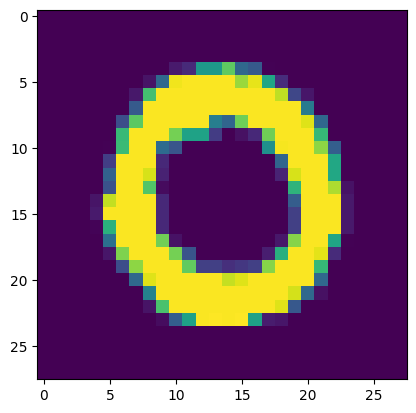

In [83]:
plt.imshow(train[1])

In [86]:
test=[]
for i in range(len(test_data)):
  test.append(test_data.iloc[i,].values.reshape(28,28))

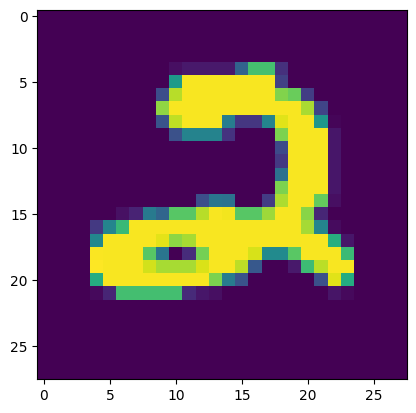

In [87]:
plt.imshow(test[0])

In [88]:
test[0].shape

(28, 28)

In [89]:
train=np.array(train)
test=np.array(test)

In [90]:
train=train/255
test=test/255

In [91]:
train=train.reshape(train.shape[0],28,28,1)
test=test.reshape(test.shape[0],28,28,1)

In [92]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(train,labels,test_size=0.2,random_state=42)

In [93]:
x_train.shape

(33600, 28, 28, 1)

In [94]:
x_test.shape

(8400, 28, 28, 1)

In [95]:
y_train.shape

(33600,)

In [96]:
model=Sequential([
    keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Conv2D(64,(3,3),activation='relu'),
    keras.layers.MaxPooling2D(2,2),
    keras.layers.Flatten(),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [97]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [98]:
history=model.fit(x_train,y_train,epochs=10,batch_size=32,validation_data=(x_test,y_test))

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 39s 35ms/step - accuracy: 0.8810 - loss: 0.3901 - val_accuracy: 0.9738 - val_loss: 0.0795
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 33s 31ms/step - accuracy: 0.9816 - loss: 0.0585 - val_accuracy: 0.9850 - val_loss: 0.0453
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 36s 35ms/step - accuracy: 0.9907 - loss: 0.0310 - val_accuracy: 0.9868 - val_loss: 0.0443
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 38s 32ms/step - accuracy: 0.9920 - loss: 0.0257 - val_accuracy: 0.9865 - val_loss: 0.0430
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - accuracy: 0.9946 - loss: 0.0170 - val_accuracy: 0.9883 - val_loss: 0.0371
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.9966 - loss: 0.0125 - val_accuracy: 0.9871 - val_loss: 0.0431
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 34s 32ms/step - accuracy: 0.9968 - loss: 0.0100 - val_accuracy: 0.9895 - val_loss: 0.0392
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.9966 -

In [99]:
preds=model.predict(test)

875/875 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step


In [100]:
preds

array([[7.2183004e-15, 4.4882460e-13, 9.9999994e-01, ..., 4.7731090e-11,
        3.3257553e-14, 2.4089127e-18],
       [9.9999994e-01, 3.4600959e-12, 1.0956919e-09, ..., 2.5686364e-10,
        1.1003900e-08, 3.3243577e-08],
       [1.5472108e-15, 9.8385079e-14, 7.5373952e-13, ..., 9.3150279e-12,
        6.5402432e-08, 9.9999911e-01],
       ...,
       [3.1541073e-28, 8.5588381e-16, 1.9815766e-27, ..., 5.7800701e-18,
        7.9819713e-17, 1.5660212e-18],
       [6.2527857e-14, 5.1230318e-12, 5.2635631e-15, ..., 2.2871580e-08,
        3.3075329e-12, 9.9999970e-01],
       [5.5485942e-19, 6.7280683e-15, 9.9999994e-01, ..., 7.0701549e-16,
        9.0749014e-12, 2.1632680e-18]], dtype=float32)

In [101]:
p=[]
for i in preds:
  p.append(np.argmax(i))

In [102]:
p

[2,
 0,
 9,
 9,
 3,
 7,
 0,
 3,
 0,
 3,
 5,
 7,
 4,
 0,
 4,
 3,
 3,
 1,
 9,
 0,
 9,
 1,
 1,
 5,
 7,
 4,
 2,
 7,
 4,
 7,
 7,
 5,
 4,
 2,
 6,
 2,
 5,
 5,
 1,
 6,
 7,
 7,
 4,
 9,
 8,
 7,
 8,
 2,
 6,
 7,
 6,
 8,
 8,
 3,
 8,
 2,
 1,
 2,
 2,
 9,
 4,
 1,
 7,
 0,
 0,
 0,
 1,
 9,
 0,
 1,
 6,
 5,
 8,
 8,
 2,
 8,
 9,
 9,
 2,
 3,
 5,
 4,
 1,
 0,
 9,
 2,
 4,
 3,
 6,
 7,
 2,
 0,
 6,
 6,
 1,
 4,
 3,
 9,
 7,
 4,
 0,
 9,
 2,
 0,
 7,
 3,
 0,
 5,
 0,
 8,
 0,
 0,
 4,
 7,
 1,
 7,
 1,
 1,
 3,
 3,
 3,
 7,
 2,
 8,
 6,
 3,
 8,
 7,
 8,
 4,
 3,
 5,
 6,
 0,
 0,
 0,
 3,
 1,
 5,
 6,
 4,
 3,
 4,
 5,
 5,
 8,
 7,
 7,
 2,
 8,
 4,
 3,
 5,
 6,
 5,
 3,
 7,
 5,
 7,
 8,
 3,
 0,
 4,
 5,
 1,
 2,
 7,
 6,
 3,
 0,
 2,
 7,
 8,
 6,
 1,
 3,
 7,
 4,
 1,
 2,
 4,
 8,
 5,
 2,
 4,
 9,
 2,
 1,
 6,
 0,
 6,
 1,
 4,
 9,
 6,
 0,
 9,
 7,
 6,
 9,
 1,
 9,
 0,
 9,
 9,
 0,
 8,
 4,
 6,
 2,
 0,
 9,
 3,
 6,
 3,
 2,
 1,
 6,
 3,
 4,
 2,
 3,
 1,
 2,
 2,
 0,
 4,
 6,
 1,
 0,
 0,
 4,
 9,
 1,
 7,
 3,
 2,
 3,
 8,
 6,
 8,
 6,
 2,
 8,
 5,
 5,
 4,
 8,
 3,
 6,


In [103]:
sub=pd.read_csv('/content/ieee-digit-competition-2/sample_submission.csv')
sub.head()

,ImageId,Label
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [104]:
sub['Label']=p

In [105]:
sub.to_csv('sub.csv',index=False)